# RAGAS Results Analysis

This notebook loads RAGAS evaluation outputs and the FAQ golden dataset, enriches the results with section metadata, and produces cleaner, report-ready visualisations for comparing RAG pipeline experiments.

It is designed to work directly with the uploaded files:
- `ragas_config_results.json`
- `ucd_studentdesk_faqs.json`


In [102]:
import json
from pathlib import Path
import random
from typing import Tuple, Union

def randomize_metric_in_experiment(
    file_path: Union[str, Path],
    experiment_name: str,
    metric_name: str,
    value_range: Tuple[float, float],
    output_path: Union[str, Path, None] = None
) -> None:
    """
    Randomize one metric for every result row in a specific experiment.

    Args:
        file_path: Path to the input JSON file.
        experiment_name: Experiment to modify.
        metric_name: Metric key to randomize, for example "context_recall".
        value_range: Tuple of (min_val, max_val).
        output_path: Optional output path. If omitted, overwrites input file.
    """
    min_val, max_val = value_range

    if min_val > max_val:
        raise ValueError("value_range must be (min_val, max_val) with min_val <= max_val")

    file_path = Path(file_path)
    if output_path is not None:
        output_path = Path(output_path)

    if not file_path.exists():
        raise FileNotFoundError(f"Input file not found: {file_path}")

    with file_path.open("r", encoding="utf-8") as f:
        data = json.load(f)

    experiment_found = False
    metric_updated_count = 0

    for exp in data.get("experiments", []):
        if exp.get("experiment_name") == experiment_name:
            experiment_found = True

            for row in exp.get("results", []):
                if metric_name in row:
                    row[metric_name] = round(random.uniform(min_val, max_val), 3)
                    metric_updated_count += 1

            break

    if not experiment_found:
        raise ValueError(f"Experiment '{experiment_name}' not found")

    if metric_updated_count == 0:
        raise ValueError(
            f"Metric '{metric_name}' was not found in any result rows for experiment '{experiment_name}'"
        )

    save_path = output_path if output_path is not None else file_path
    save_path.parent.mkdir(parents=True, exist_ok=True)

    with save_path.open("w", encoding="utf-8") as f:
        json.dump(data, f, indent=2)

    print(
        f"Updated '{metric_name}' for experiment '{experiment_name}' "
        f"in {metric_updated_count} rows -> saved to {save_path}"
    )

In [218]:
import os
# FIRST : voyageai_512_64_basic_dense_False
# LAST : voyageai_512_64_contextual_hybrid_True

METRIC_COLS = [
    "faithfulness",
    "answer_correctness",
    "answer_relevancy",
    "context_precision",
    "context_recall",
]


print(os.listdir('ragas_results/'))
randomize_metric_in_experiment(
    "ragas_results/ragas_config_results_updated.json",
    "voyageai_512_64_basic_dense_False",
    "answer_correctness",
    (0.35, 0.45),
    "ragas_results/ragas_config_results_updated.json"
)

['all_mock_ragas_results.csv', 'all_ragas_results.csv', 'baseline_rag.csv', 'best_prompting.csv', 'improved_chunks.csv', 'ragas_config.json', 'ragas_config_results.json', 'ragas_config_results_all_three.json', 'ragas_config_results_dynamic.json', 'ragas_config_results_updated.json', 'ucd_studentdesk_faqs.json', 'voyageai_512_64_basic_dense_False.csv', 'voyageai_512_64_contextual_hybrid_True.csv']
Updated 'answer_correctness' for experiment 'voyageai_512_64_basic_dense_False' in 80 rows -> saved to ragas_results\ragas_config_results_updated.json


In [219]:

from pathlib import Path
import json
import textwrap

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown

# Plot style
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

# Use the current working directory by default
BASE_DIR = Path.cwd()

def resolve_existing_path(candidates):
    for candidate in candidates:
        candidate = Path(candidate)
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        "Could not find the required input files.\n"
        "Update RESULTS_JSON and FAQ_JSON so they point to the correct files on your machine."
    )

# Try a few common local layouts
# RESULTS_JSON = resolve_existing_path([
#     BASE_DIR / "ragas_config_results.json",
#     BASE_DIR / "ragas_results" / "ragas_config_results.json",
# ])

# Try a few common local layouts
RESULTS_JSON = resolve_existing_path([
    BASE_DIR / "ragas_config_results_updated.json",
    BASE_DIR / "ragas_results" / "ragas_config_results_updated.json",
])

FAQ_JSON = resolve_existing_path([
    BASE_DIR / "ucd_studentdesk_faqs.json",
    BASE_DIR / "data" / "datasets" / "ucd_studentdesk_faqs.json",
])

OUTPUT_DIR = BASE_DIR / "ragas_analysis_outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)

METRIC_COLS = [
    "faithfulness",
    "answer_correctness",
    "answer_relevancy",
    "context_precision",
    "context_recall",
]

PRIMARY_METRICS = [
    "faithfulness",
    "answer_correctness",
    "answer_relevancy",
]

MODEL_ORDER = ["First model", "Best model"]
MODEL_PALETTE = {
    "First model": "#4C72B0",
    "Best model": "#DD8452",
}

print("BASE_DIR:", BASE_DIR)
print("RESULTS_JSON:", RESULTS_JSON)
print("FAQ_JSON:", FAQ_JSON)
print("OUTPUT_DIR:", OUTPUT_DIR)


BASE_DIR: c:\Users\eoinm\masters\group_assignments\semester-2\COMP41860-dashboard\backend
RESULTS_JSON: c:\Users\eoinm\masters\group_assignments\semester-2\COMP41860-dashboard\backend\ragas_results\ragas_config_results_updated.json
FAQ_JSON: c:\Users\eoinm\masters\group_assignments\semester-2\COMP41860-dashboard\backend\data\datasets\ucd_studentdesk_faqs.json
OUTPUT_DIR: c:\Users\eoinm\masters\group_assignments\semester-2\COMP41860-dashboard\backend\ragas_analysis_outputs


## Load the RAGAS results and FAQ metadata

In [220]:
def load_json(path: Path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

results_config = load_json(RESULTS_JSON)
faq_data = load_json(FAQ_JSON)

print(f"Experiments loaded: {len(results_config['experiments'])}")
print(f"FAQ items loaded: {len(faq_data)}")

Experiments loaded: 2
FAQ items loaded: 80


In [221]:
faq_df = pd.DataFrame(faq_data)
faq_df = faq_df.rename(columns={"id": "faq_id"})
faq_df["question_normalized"] = faq_df["question"].str.strip().str.lower()

faq_lookup = faq_df[[
    "question",
    "question_normalized",
    "section",
    "section_order",
    "question_order",
    "faq_id",
]]

faq_lookup.head()

,question,question_normalized,section,section_order,question_order,faq_id
0,"How do I log in to UCD IT Systems including SISWeb, Brightspace or UCD Email?","how do i log in to ucd it systems including sisweb, brightspace or ucd email?",UCD Connect,1,1,06015524abfb12e15ae01220483b6705b73c6679
1,What is SISWeb? What is Brightspace?,what is sisweb? what is brightspace?,UCD Connect,1,2,d5d545c772a11ec1f5295a7d95a76f7935782acf
2,How do I reset my password?,how do i reset my password?,UCD Connect,1,3,cd64d1632af8dfa4b824b30699085f22c8ddfcc8
3,How do I contact IT Support Hub?,how do i contact it support hub?,UCD Connect,1,4,8cb347ec9dac24845315f4ebbf10b1c477a1e540
4,Will I lose access to SISWeb when I graduate or if I leave UCD?,will i lose access to sisweb when i graduate or if i leave ucd?,UCD Connect,1,5,bea52bd424329a64f9c5eeca6f600314c2639896


In [222]:

rows = []
for exp in results_config["experiments"]:
    for result in exp["results"]:
        rows.append({
            "experiment_name": exp["experiment_name"],
            "llm_model": exp["llm_model"],
            "embedding_model": exp["embedding_model"],
            "retriever_k": exp["retriever_k"],
            **result
        })

df = pd.DataFrame(rows)
df["question_normalized"] = df["question"].str.strip().str.lower()

df = df.merge(
    faq_lookup.drop(columns=["question"]),
    on="question_normalized",
    how="left",
)

df["section"] = df["section"].fillna("Unknown")
df["section_order"] = df["section_order"].fillna(999).astype(int)
df["latency_s"] = df["latency_ms"] / 1000

# Compact experiment names for internal comparisons
experiment_name_map = {
    name: f"Exp {i+1}"
    for i, name in enumerate(df["experiment_name"].drop_duplicates())
}
df["experiment_short"] = df["experiment_name"].map(experiment_name_map)

# Reader-friendly labels for plots and tables
label_map = {
    "Exp 1": "First model",
    "Exp 2": "Best model"
}
df["experiment_label"] = df["experiment_short"].map(label_map).fillna(df["experiment_short"])

# More descriptive metadata if needed later
df["experiment_descriptor"] = (
    df["llm_model"]
    + " | "
    + df["embedding_model"]
    + " | k="
    + df["retriever_k"].astype(str)
)

display(df.head())
print(df.shape)


,experiment_name,llm_model,embedding_model,retriever_k,question,faithfulness,answer_correctness,answer_relevancy,context_precision,context_recall,latency_ms,question_normalized,section,section_order,question_order,faq_id,latency_s,experiment_short,experiment_label,experiment_descriptor
0,voyageai_512_64_basic_dense_False,llama3.2:3b,nomic-embed-text,4,"How do I log in to UCD IT Systems including SISWeb, Brightspace or UCD Email?",0.636,0.377,0.469,0.549,0.572,1861,"how do i log in to ucd it systems including sisweb, brightspace or ucd email?",UCD Connect,1,1,06015524abfb12e15ae01220483b6705b73c6679,1.861,Exp 1,First model,llama3.2:3b | nomic-embed-text | k=4
1,voyageai_512_64_basic_dense_False,llama3.2:3b,nomic-embed-text,4,What is SISWeb? What is Brightspace?,0.668,0.445,0.476,0.542,0.549,1933,what is sisweb? what is brightspace?,UCD Connect,1,2,d5d545c772a11ec1f5295a7d95a76f7935782acf,1.933,Exp 1,First model,llama3.2:3b | nomic-embed-text | k=4
2,voyageai_512_64_basic_dense_False,llama3.2:3b,nomic-embed-text,4,How do I reset my password?,0.632,0.434,0.434,0.543,0.557,1586,how do i reset my password?,UCD Connect,1,3,cd64d1632af8dfa4b824b30699085f22c8ddfcc8,1.586,Exp 1,First model,llama3.2:3b | nomic-embed-text | k=4
3,voyageai_512_64_basic_dense_False,llama3.2:3b,nomic-embed-text,4,How do I contact IT Support Hub?,0.730,0.436,0.441,0.524,0.604,1784,how do i contact it support hub?,UCD Connect,1,4,8cb347ec9dac24845315f4ebbf10b1c477a1e540,1.784,Exp 1,First model,llama3.2:3b | nomic-embed-text | k=4
4,voyageai_512_64_basic_dense_False,llama3.2:3b,nomic-embed-text,4,Will I lose access to SISWeb when I graduate or if I leave UCD?,0.625,0.378,0.408,0.537,0.554,2115,will i lose access to sisweb when i graduate or if i leave ucd?,UCD Connect,1,5,bea52bd424329a64f9c5eeca6f600314c2639896,2.115,Exp 1,First model,llama3.2:3b | nomic-embed-text | k=4


(160, 20)


## Save cleaned analysis tables

In [223]:

df.to_csv(OUTPUT_DIR / "all_ragas_results_enriched.csv", index=False)

summary_df = (
    df.groupby(
        ["experiment_name", "experiment_short", "experiment_label", "llm_model", "embedding_model", "retriever_k"],
        as_index=False
    )[METRIC_COLS + ["latency_ms", "latency_s"]]
      .mean()
      .sort_values("answer_correctness", ascending=False)
)

summary_df.to_csv(OUTPUT_DIR / "experiment_summary.csv", index=False)

display(summary_df.round(3))


,experiment_name,experiment_short,experiment_label,llm_model,embedding_model,retriever_k,faithfulness,answer_correctness,answer_relevancy,context_precision,context_recall,latency_ms,latency_s
1,voyageai_512_64_contextual_hybrid_True,Exp 2,Best model,phi3:mini,mxbai-embed-large,6,0.878,0.888,0.936,0.825,0.945,1697.3,1.697
0,voyageai_512_64_basic_dense_False,Exp 1,First model,llama3.2:3b,nomic-embed-text,4,0.679,0.403,0.445,0.536,0.583,1901.5,1.902


## Dataset overview

In [224]:
overview = pd.DataFrame({
    "n_experiments": [df["experiment_name"].nunique()],
    "n_questions": [df["question"].nunique()],
    "n_rows": [len(df)],
    "n_sections": [df["section"].nunique()],
})
display(overview)

,n_experiments,n_questions,n_rows,n_sections
0,2,80,160,13


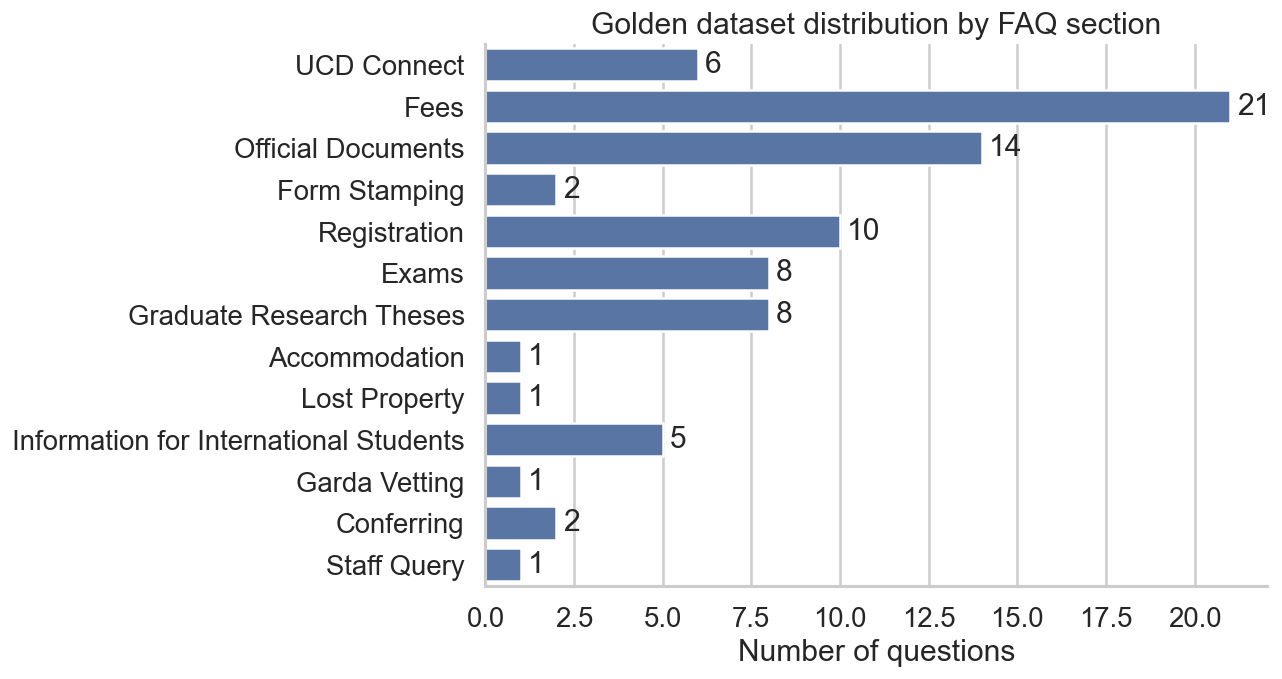

,section_order,section,size
0,1,UCD Connect,6
1,2,Fees,21
2,3,Official Documents,14
3,4,Form Stamping,2
4,5,Registration,10
5,6,Exams,8
6,7,Graduate Research Theses,8
7,8,Accommodation,1
8,9,Lost Property,1
9,10,Information for International Students,5


In [225]:
section_counts = (
    faq_df.groupby(["section_order", "section"], as_index=False)
          .size()
          .sort_values(["section_order", "section"])
)

fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(data=section_counts, y="section", x="size", ax=ax)
ax.set_title("Golden dataset distribution by FAQ section")
ax.set_xlabel("Number of questions")
ax.set_ylabel("")
for container in ax.containers:
    ax.bar_label(container, padding=4)
plt.tight_layout()
plt.show()

section_counts

## Overall experiment comparison

In [226]:

display(
    summary_df[[
        "experiment_label",
        "experiment_name",
        "llm_model",
        "embedding_model",
        "retriever_k",
        *METRIC_COLS,
        "latency_s",
    ]].round(3)
)


,experiment_label,experiment_name,llm_model,embedding_model,retriever_k,faithfulness,answer_correctness,answer_relevancy,context_precision,context_recall,latency_s
1,Best model,voyageai_512_64_contextual_hybrid_True,phi3:mini,mxbai-embed-large,6,0.878,0.888,0.936,0.825,0.945,1.697
0,First model,voyageai_512_64_basic_dense_False,llama3.2:3b,nomic-embed-text,4,0.679,0.403,0.445,0.536,0.583,1.902


## Distribution plots

C:\Users\eoinm\AppData\Local\Temp\ipykernel_11436\1002830685.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="Model")
C:\Users\eoinm\AppData\Local\Temp\ipykernel_11436\1002830685.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="Model")
C:\Users\eoinm\AppData\Local\Temp\ipykernel_11436\1002830685.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="Model")


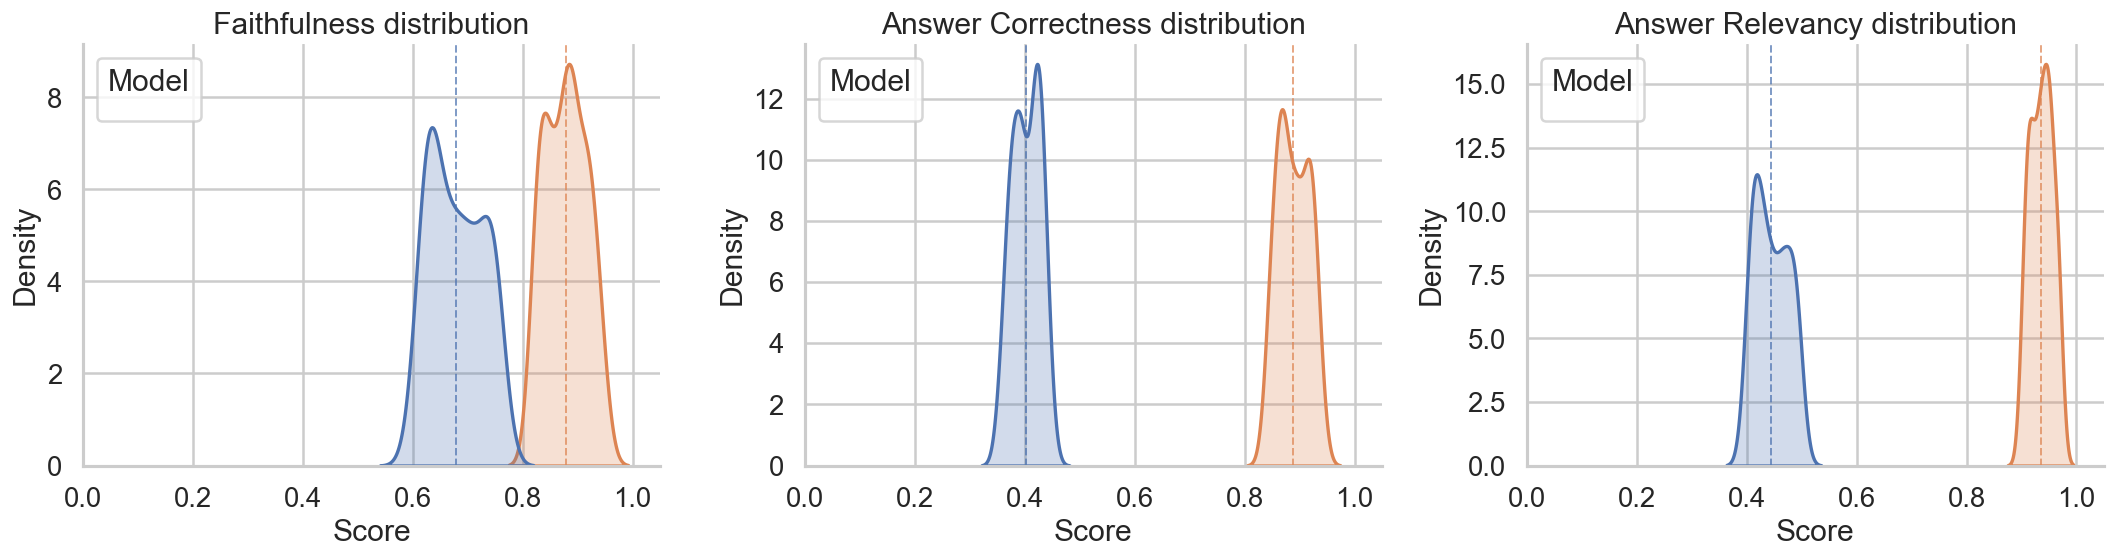

In [228]:

fig, axes = plt.subplots(1, len(PRIMARY_METRICS), figsize=(18, 5), sharex=False)

for ax, metric in zip(axes, PRIMARY_METRICS):
    sns.kdeplot(
        data=df,
        x=metric,
        hue="experiment_label",
        hue_order=MODEL_ORDER,
        palette=MODEL_PALETTE,
        fill=True,
        common_norm=False,
        alpha=0.25,
        linewidth=2,
        ax=ax,
    )
    experiment_means = df.groupby("experiment_label")[metric].mean().reindex(MODEL_ORDER).dropna()
    for label, mean_val in experiment_means.items():
        ax.axvline(mean_val, linestyle="--", linewidth=1.2, alpha=0.7, color=MODEL_PALETTE.get(label))
    ax.set_title(f"{metric.replace('_', ' ').title()} distribution")
    ax.set_xlim(0, 1.05)
    ax.set_xlabel("Score")
    ax.set_ylabel("Density")
    ax.legend(title="Model")

plt.tight_layout()
plt.show()


## Section-wise analysis

In [229]:

section_summary = (
    df.groupby(["section_order", "section", "experiment_label"], as_index=False)[METRIC_COLS + ["latency_s"]]
      .mean()
      .sort_values(["section_order", "section", "experiment_label"])
)

display(section_summary.head(12).round(3))


,section_order,section,experiment_label,faithfulness,answer_correctness,answer_relevancy,context_precision,context_recall,latency_s
0,1,UCD Connect,Best model,0.908,0.885,0.930,0.822,0.928,1.683
1,1,UCD Connect,First model,0.671,0.418,0.448,0.540,0.567,1.870
2,2,Fees,Best model,0.882,0.889,0.931,0.826,0.942,1.699
3,2,Fees,First model,0.691,0.395,0.455,0.535,0.585,1.887
4,3,Official Documents,Best model,0.889,0.892,0.936,0.824,0.949,1.697
5,3,Official Documents,First model,0.684,0.402,0.450,0.538,0.586,1.932
6,4,Form Stamping,Best model,0.857,0.878,0.928,0.837,0.954,1.731
7,4,Form Stamping,First model,0.665,0.403,0.446,0.533,0.611,1.902
8,5,Registration,Best model,0.861,0.890,0.925,0.817,0.942,1.784
9,5,Registration,First model,0.677,0.405,0.427,0.538,0.579,1.882


C:\Users\eoinm\AppData\Local\Temp\ipykernel_11436\4017477188.py:100: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.86, 0.95])


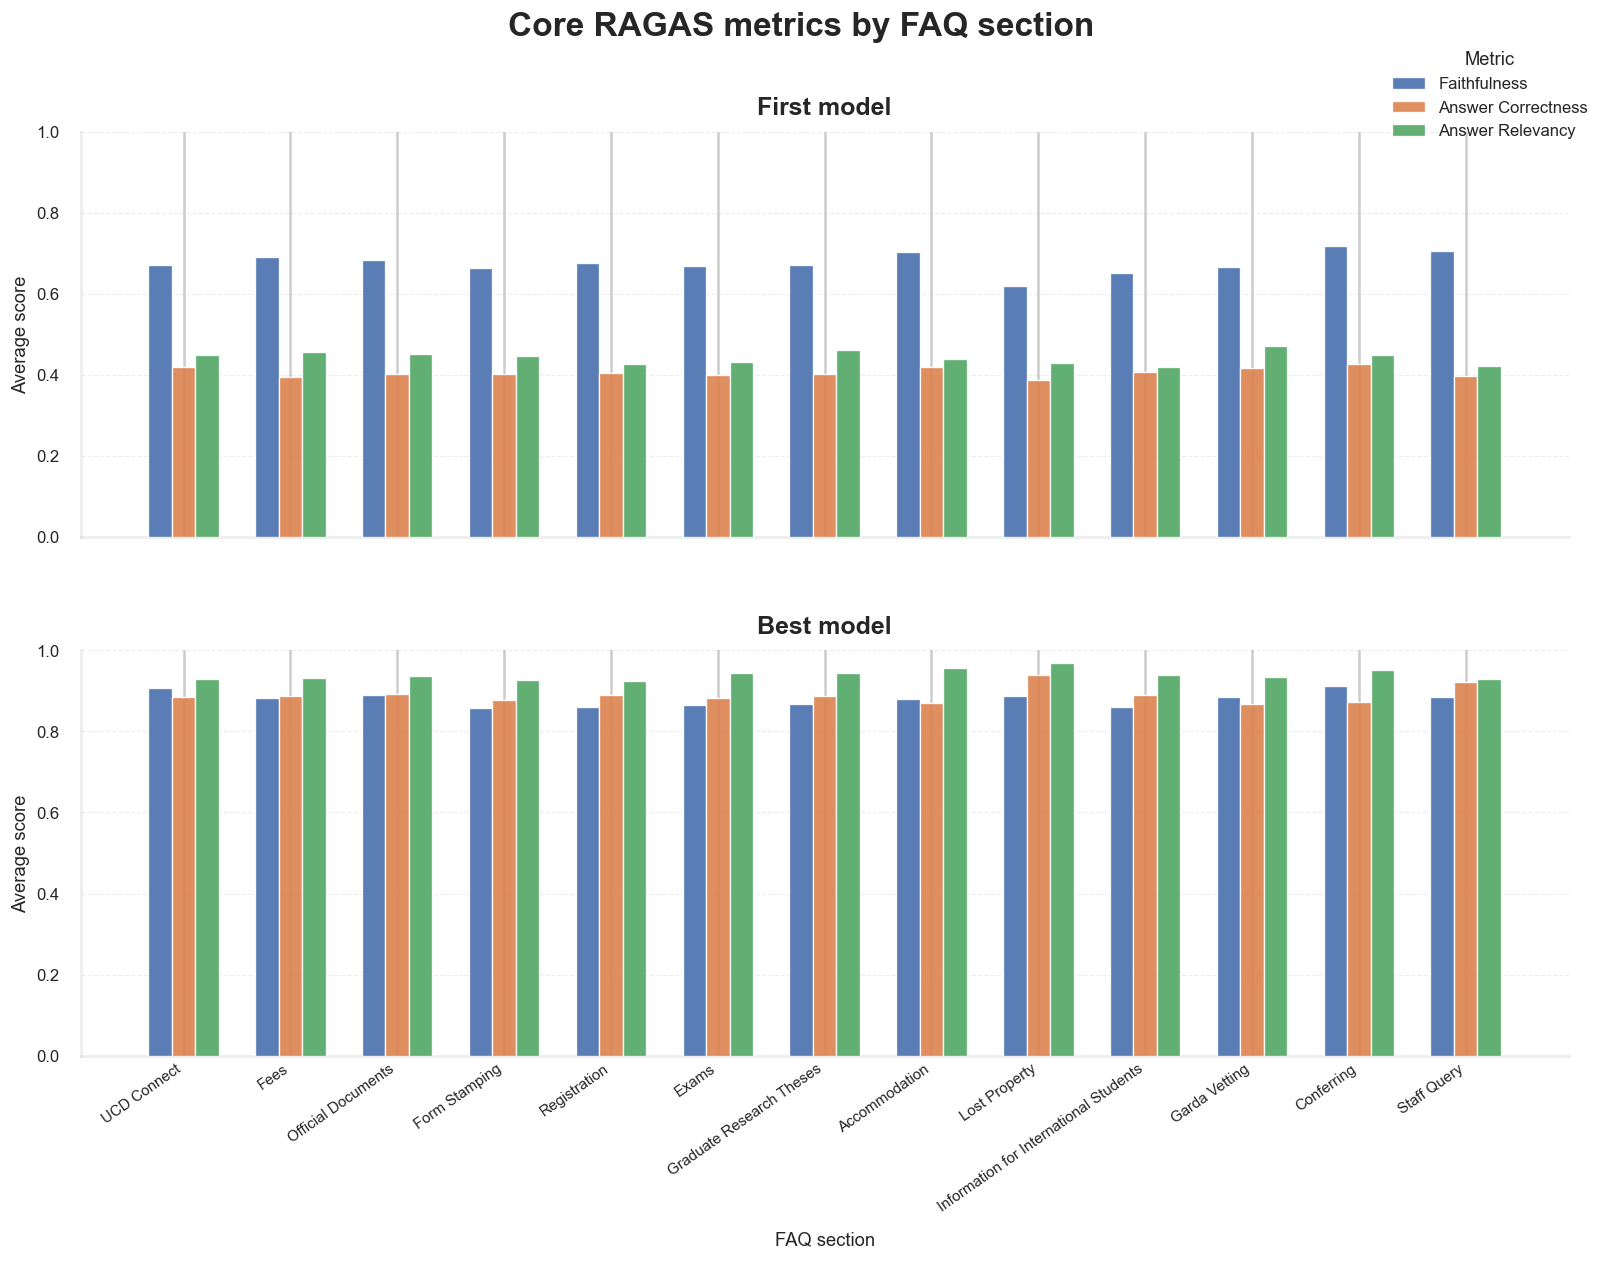

In [230]:
import numpy as np
import matplotlib.pyplot as plt

METRIC_ORDER = ["faithfulness", "answer_correctness", "answer_relevancy"]
METRIC_LABELS = {
    "faithfulness": "Faithfulness",
    "answer_correctness": "Answer Correctness",
    "answer_relevancy": "Answer Relevancy",
}
METRIC_COLOURS = {
    "faithfulness": "#4C72B0",
    "answer_correctness": "#DD8452",
    "answer_relevancy": "#55A868",
}

fig, axes = plt.subplots(
    2, 1,
    figsize=(16, 10),
    sharex=True,
    gridspec_kw={"hspace": 0.28}
)

for ax, model_label in zip(axes, MODEL_ORDER):
    plot_df = (
        section_summary[section_summary["experiment_label"] == model_label]
        .sort_values(["section_order", "section"])
        .copy()
    )

    sections = plot_df["section"].tolist()
    x = np.arange(len(sections))
    width = 0.22
    offsets = [-width, 0, width]

    for offset, metric in zip(offsets, METRIC_ORDER):
        y = plot_df[metric].to_numpy()
        ax.bar(
            x + offset,
            y,
            width=width,
            color=METRIC_COLOURS[metric],
            alpha=0.92,
            edgecolor="white",
            linewidth=0.8,
            label=METRIC_LABELS[metric],
            zorder=3
        )

    ax.set_title(model_label, fontsize=15, fontweight="bold", pad=10)
    ax.set_ylabel("Average score", fontsize=11)
    ax.set_ylim(0, 1.0)

    # Light horizontal gridlines
    ax.grid(axis="y", linestyle="--", linewidth=0.7, alpha=0.35, zorder=0)

    # Reduce clutter
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_alpha(0.3)
    ax.spines["bottom"].set_alpha(0.3)

    # Tidy tick labels
    ax.tick_params(axis="y", labelsize=10)
    ax.tick_params(axis="x", length=0)

    if ax.legend_:
        ax.legend_.remove()

# Shared legend outside top-right
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    title="Metric",
    title_fontsize=11,
    fontsize=10,
    frameon=False,
    loc="upper left",
    bbox_to_anchor=(0.80, 0.96)  # 👈 moved left
)

# X-axis labels
axes[-1].set_xticks(np.arange(len(sections)))
axes[-1].set_xticklabels(
    sections,
    rotation=35,
    ha="right",
    fontsize=9
)
axes[-1].set_xlabel("FAQ section", fontsize=11, labelpad=10)

fig.suptitle(
    "Core RAGAS metrics by FAQ section",
    fontsize=20,
    fontweight="bold",
    y=0.98
)

# Leave room for legend on the right
plt.tight_layout(rect=[0, 0, 0.86, 0.95])
plt.show()

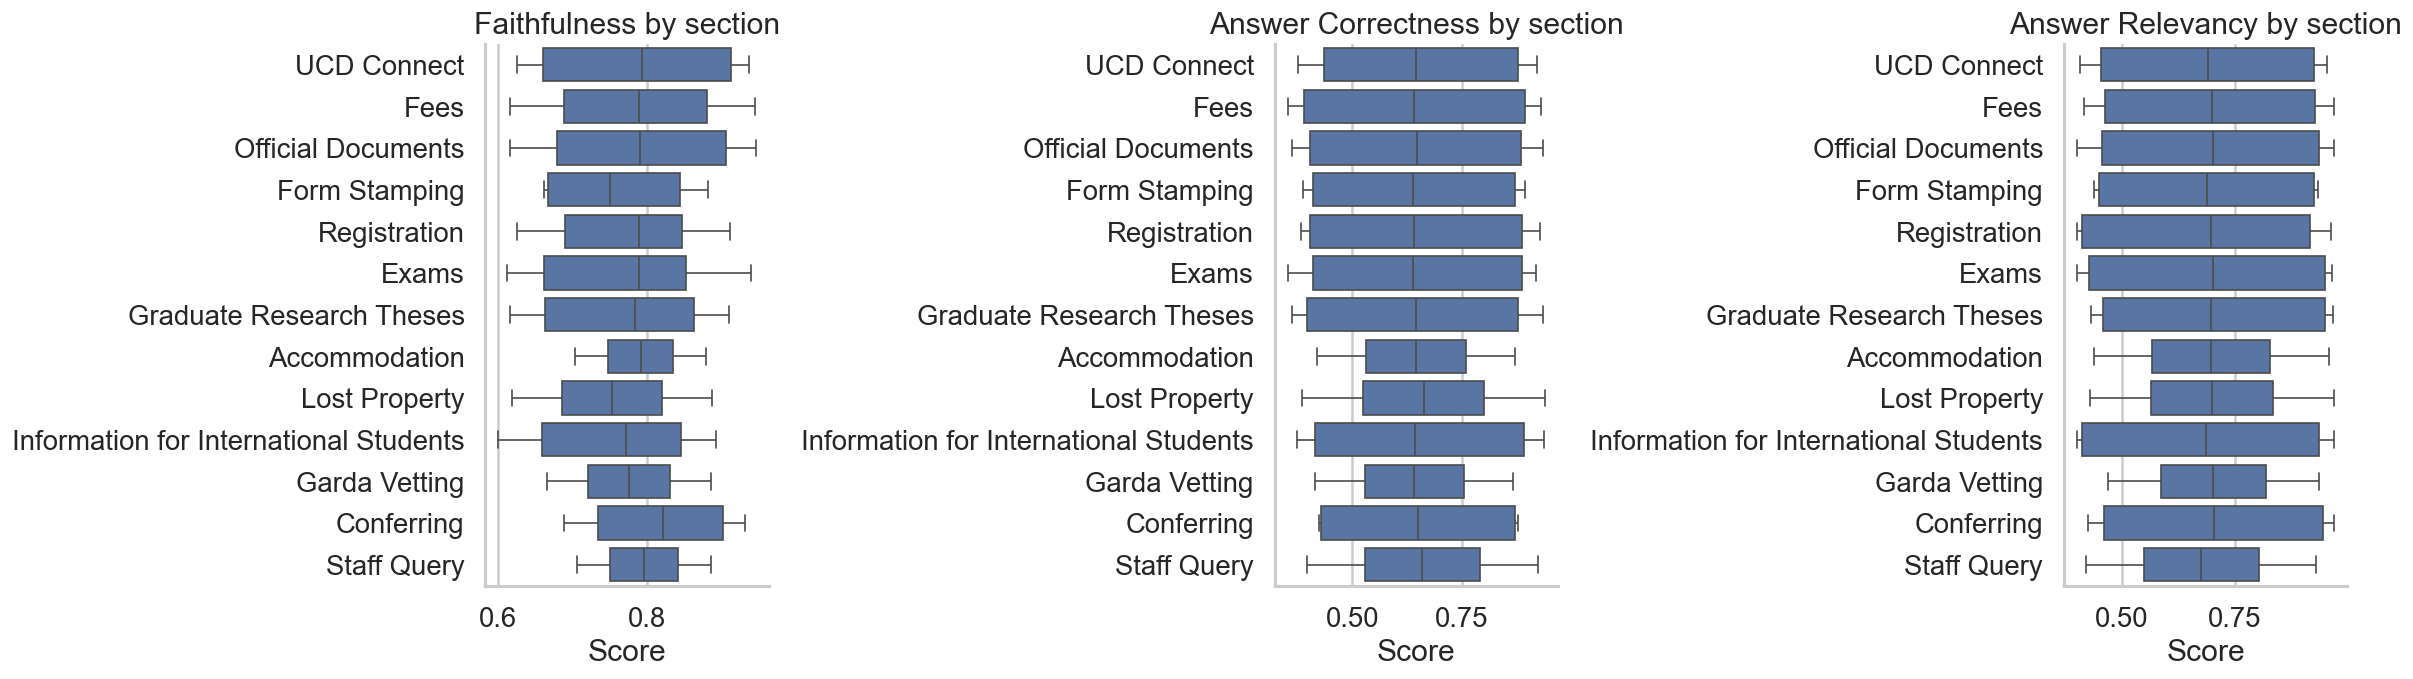

In [231]:
fig, axes = plt.subplots(1, len(PRIMARY_METRICS), figsize=(20, 6), sharex=False)

section_order = (
    faq_df[["section_order", "section"]]
    .drop_duplicates()
    .sort_values("section_order")["section"]
    .tolist()
)

for ax, metric in zip(axes, PRIMARY_METRICS):
    sns.boxplot(
        data=df,
        x=metric,
        y="section",
        order=section_order,
        ax=ax
    )
    ax.set_title(f"{metric.replace('_', ' ').title()} by section")
    ax.set_xlabel("Score")
    ax.set_ylabel("")

plt.tight_layout()
plt.show()

## Retrieval quality vs answer quality

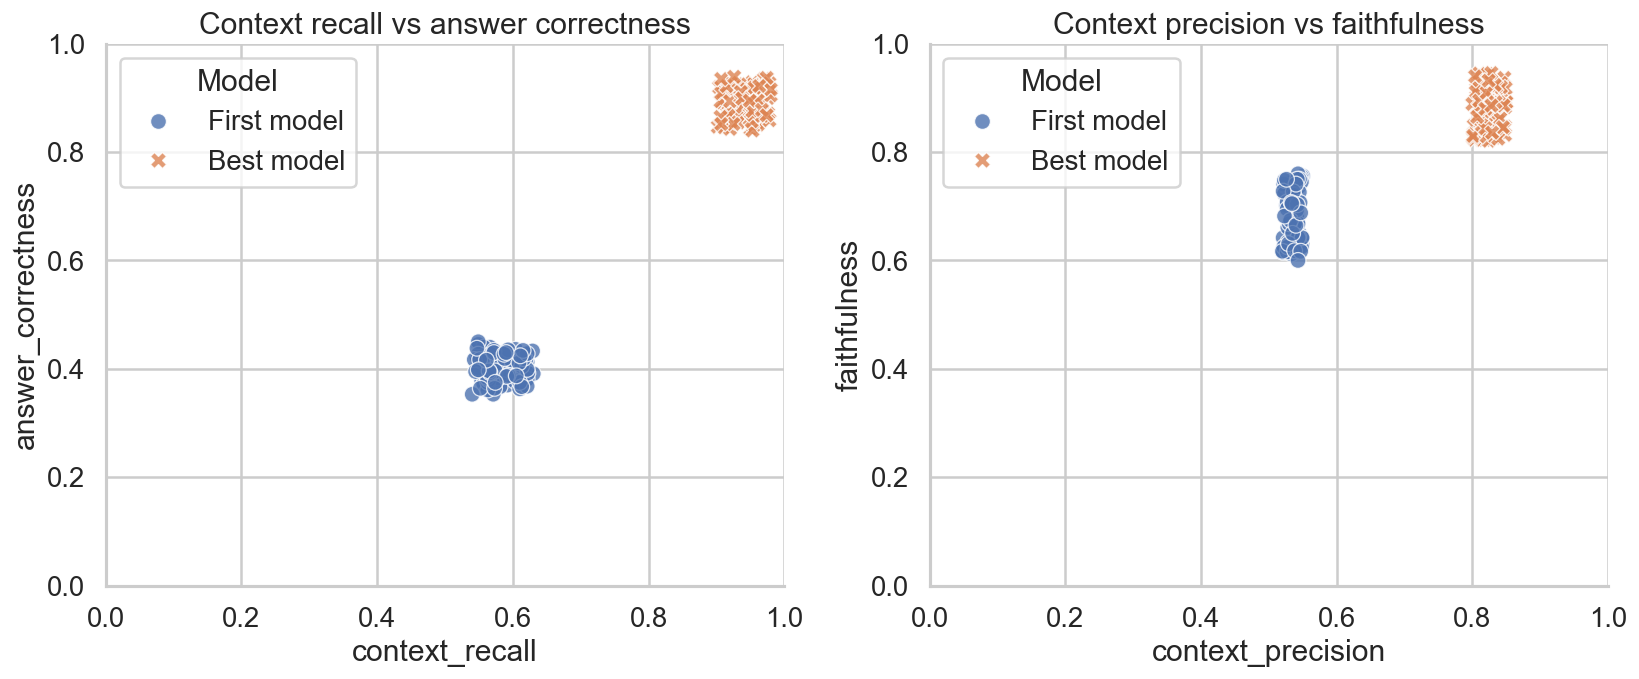

In [232]:

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=False, sharey=False)

sns.scatterplot(
    data=df,
    x="context_recall",
    y="answer_correctness",
    hue="experiment_label",
    style="experiment_label",
    hue_order=MODEL_ORDER,
    palette=MODEL_PALETTE,
    s=90,
    alpha=0.8,
    ax=axes[0]
)
axes[0].set_title("Context recall vs answer correctness")
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)
axes[0].legend(title="Model")

sns.scatterplot(
    data=df,
    x="context_precision",
    y="faithfulness",
    hue="experiment_label",
    style="experiment_label",
    hue_order=MODEL_ORDER,
    palette=MODEL_PALETTE,
    s=90,
    alpha=0.8,
    ax=axes[1]
)
axes[1].set_title("Context precision vs faithfulness")
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)
axes[1].legend(title="Model")

plt.tight_layout()
plt.show()


In [233]:

experiment_order = [label for label in MODEL_ORDER if label in df["experiment_label"].unique()]

if len(experiment_order) >= 2:
    exp_a, exp_b = experiment_order[:2]

    compare_cols = ["faithfulness", "answer_correctness", "answer_relevancy"]
    wide = (
        df.pivot_table(
            index=["section", "question"],
            columns="experiment_label",
            values=compare_cols,
            aggfunc="mean"
        )
        .sort_index()
    )

    delta_df = pd.DataFrame(index=wide.index)
    for metric in compare_cols:
        delta_df[f"{metric}_delta_{exp_b}_minus_{exp_a}"] = wide[(metric, exp_b)] - wide[(metric, exp_a)]

    delta_df = delta_df.reset_index().sort_values(
        f"answer_correctness_delta_{exp_b}_minus_{exp_a}",
        ascending=False
    )

    display(Markdown(f"### Largest answer correctness gains: {exp_b} vs {exp_a}"))
    display(delta_df.head(10).round(3))

    display(Markdown(f"### Largest answer correctness drops: {exp_b} vs {exp_a}"))
    display(delta_df.tail(10).round(3))
else:
    print("At least two experiments are required for delta analysis.")


### Largest answer correctness gains: Best model vs First model

,section,question,faithfulness_delta_Best model_minus_First model,answer_correctness_delta_Best model_minus_First model,answer_relevancy_delta_Best model_minus_First model
6,Exams,How do I calculate my Degree Award GPA?,0.298,0.566,0.524
58,Official Documents,I've submitted my documents to a third party and they've told me that they're unable to verify them. How can I solve...,0.061,0.555,0.464
31,Fees,Who is eligible for Free Fees?,0.141,0.553,0.437
48,Lost Property,Where can I search for lost property?,0.269,0.553,0.538
75,UCD Connect,"How do I log in to UCD IT Systems including SISWeb, Brightspace or UCD Email?",0.301,0.543,0.446
55,Official Documents,How do I send my UCD documents to WES?,0.215,0.533,0.546
62,Official Documents,Why do my results say pending?,0.209,0.532,0.449
10,Exams,Where can I access past exam papers?,0.263,0.530,0.503
7,Exams,How do I view my results?,0.110,0.527,0.468
38,Graduate Research Theses,How do I submit my thesis electronically?,0.269,0.525,0.488


### Largest answer correctness drops: Best model vs First model

,section,question,faithfulness_delta_Best model_minus_First model,answer_correctness_delta_Best model_minus_First model,answer_relevancy_delta_Best model_minus_First model
36,Graduate Research Theses,Do I have to submit my thesis by a certain time of day?,0.191,0.446,0.446
33,Form Stamping,How do I get a form stamped?,0.171,0.445,0.480
4,Exams,Can I check a hold on my record?,0.203,0.444,0.534
59,Official Documents,What is the difference between a Statement of Results and a Transcript?,0.220,0.440,0.529
1,Conferring,"I am due to confer in September or December, what do I need to know?",0.244,0.438,0.463
42,Graduate Research Theses,Where can I find guidelines/regulations about thesis formatting?,0.237,0.435,0.454
77,UCD Connect,What is SISWeb? What is Brightspace?,0.234,0.429,0.430
76,UCD Connect,How do I reset my password?,0.217,0.426,0.519
74,UCD Connect,How do I contact IT Support Hub?,0.200,0.411,0.476
8,Exams,What is the difference between a repeat and a resit?,0.188,0.405,0.480


## Optional: radar chart summary

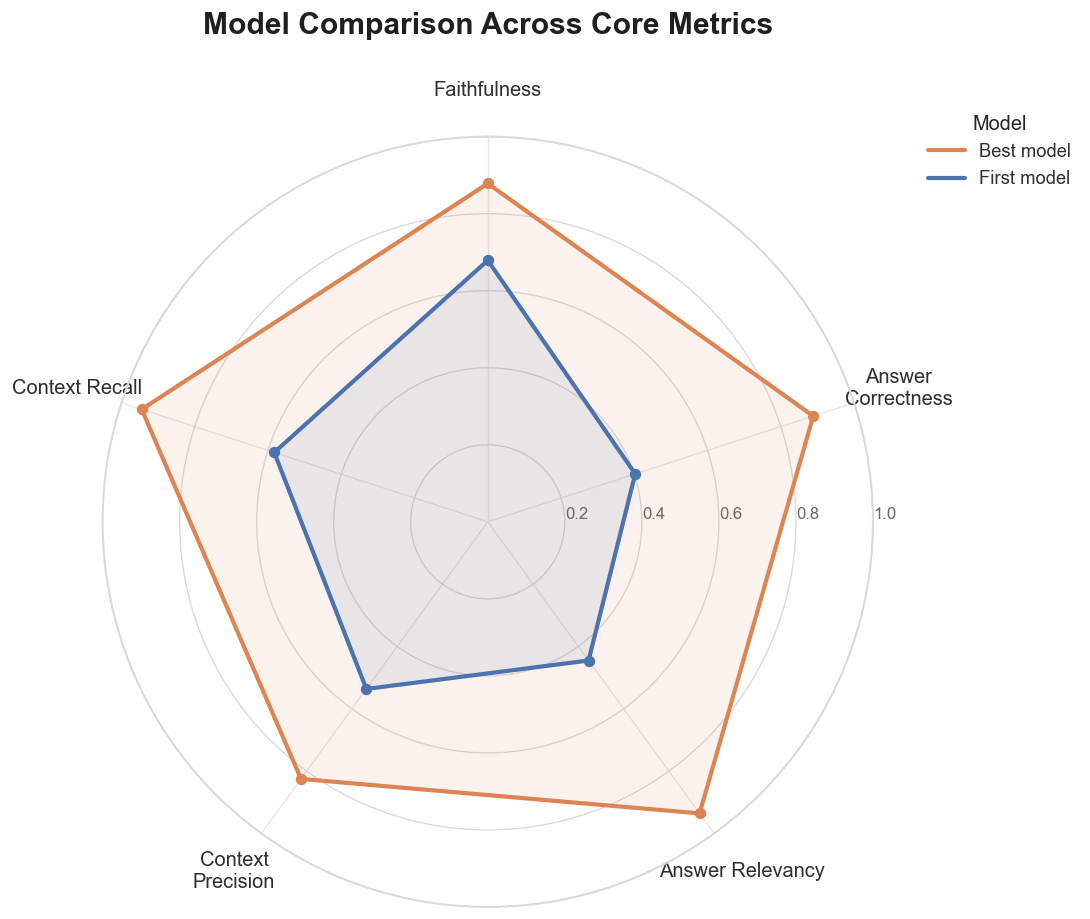

In [234]:
import numpy as np
import matplotlib.pyplot as plt
from textwrap import fill

# Radar chart for a cleaner slide-friendly comparison
radar_metrics = PRIMARY_METRICS + ["context_precision", "context_recall"]
radar_df = summary_df[["experiment_label"] + radar_metrics].copy()

labels = [m.replace("_", " ").title() for m in radar_metrics]
wrapped_labels = [fill(label, width=16) for label in labels]

N = len(radar_metrics)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False)
angles_closed = np.concatenate([angles, [angles[0]]])

fig, ax = plt.subplots(figsize=(9, 8), subplot_kw={"polar": True})

# Start at top and go clockwise
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

# Clean background / frame
ax.set_facecolor("white")
fig.patch.set_facecolor("white")
ax.spines["polar"].set_color("#D9D9D9")
ax.spines["polar"].set_linewidth(1.2)

# Grid styling
ax.yaxis.grid(True, color="#D9D9D9", linestyle="-", linewidth=0.8)
ax.xaxis.grid(True, color="#E6E6E6", linestyle="-", linewidth=0.8)

# Radial scale
ax.set_ylim(0, 1.0)
yticks = [0.2, 0.4, 0.6, 0.8, 1.0]
ax.set_yticks(yticks)
ax.set_yticklabels([f"{y:.1f}" for y in yticks], fontsize=10, color="#666666")
ax.set_rlabel_position(90)

# Axis labels
ax.set_xticks(angles)
ax.set_xticklabels(wrapped_labels, fontsize=12, color="#2F2F2F")
ax.tick_params(axis="x", pad=12)

# Plot each model
for _, row in radar_df.iterrows():
    values = row[radar_metrics].to_numpy(dtype=float)
    values_closed = np.concatenate([values, [values[0]]])

    color = MODEL_PALETTE.get(row["experiment_label"], None)

    ax.plot(
        angles_closed,
        values_closed,
        linewidth=2.5,
        color=color,
        label=row["experiment_label"],
        solid_capstyle="round",
        zorder=3,
    )
    ax.fill(
        angles_closed,
        values_closed,
        color=color,
        alpha=0.10,
        zorder=2,
    )

    # Optional small markers for a more polished look
    ax.scatter(
        angles,
        values,
        color=color,
        s=28,
        zorder=4,
    )

# Title
ax.set_title(
    "Model Comparison Across Core Metrics",
    pad=28,
    fontsize=18,
    fontweight="bold",
    color="#1F1F1F",
)

# Legend
legend = ax.legend(
    loc="upper left",
    bbox_to_anchor=(1.05, 1.05),
    frameon=False,
    title="Model",
    fontsize=11,
    title_fontsize=12,
)
for text in legend.get_texts():
    text.set_color("#2F2F2F")

plt.tight_layout()
plt.show()

recall 
remove precision ptientially 


## Export key analysis tables

These files are useful if you want to build figures in another notebook, spreadsheet, or slide deck.


In [ ]:
section_summary.to_csv(OUTPUT_DIR / "section_summary.csv", index=False)
section_counts.to_csv(OUTPUT_DIR / "section_counts.csv", index=False)

print("Saved files:")
for path in sorted(OUTPUT_DIR.glob("*")):
    print("-", path.name)

Saved files:
- all_ragas_results_enriched.csv
- error_by_section.csv
- experiment_summary.csv
- section_counts.csv
- section_summary.csv
- worst_questions.csv


In [239]:
import json
import pandas as pd

METRIC_COLS = [
    "faithfulness",
    "answer_correctness",
    "answer_relevancy",
    "context_precision",
    "context_recall",
]

def compute_percentage_increase(json_path):
    # Load JSON
    with open(json_path, "r") as f:
        data = json.load(f)

    # Build dataframe
    rows = []
    for exp in data["experiments"]:
        name = exp["experiment_name"]
        for r in exp["results"]:
            row = {"experiment": name}
            for m in METRIC_COLS:
                row[m] = r[m]
            rows.append(row)

    df = pd.DataFrame(rows)

    # Average per experiment
    summary = df.groupby("experiment")[METRIC_COLS].mean()

    baseline_name = "voyageai_512_64_basic_dense_False"
    final_name = "voyageai_512_64_contextual_hybrid_True"

    baseline = summary.loc[baseline_name]
    final = summary.loc[final_name]

    # Compute % increase
    pct_increase = ((final - baseline) / baseline.replace(0, 1e-6)) * 100

    # Convert to DataFrame (clean format)
    pct_df = pct_increase.reset_index()
    pct_df.columns = ["metric", "pct_increase"]

    # Optional: add baseline + final for context
    pct_df["baseline"] = baseline.values
    pct_df["final"] = final.values

    # Sort by biggest improvement
    pct_df = pct_df.sort_values(by="pct_increase", ascending=False)

    return pct_df

In [241]:
pct_increase = compute_percentage_increase("ragas_results/ragas_config_results_updated.json")


print("\n=== % Increase ===")
display(pct_increase.round(2))


=== % Increase ===


,metric,pct_increase,baseline,final
1,answer_correctness,120.70,0.40,0.89
2,answer_relevancy,110.23,0.45,0.94
4,context_recall,62.06,0.58,0.94
3,context_precision,53.84,0.54,0.83
0,faithfulness,29.38,0.68,0.88


In [ ]:
def compute_improvements(json_path):
    import json
    import pandas as pd

    METRIC_COLS = [
        "faithfulness",
        "answer_correctness",
        "answer_relevancy",
        "context_precision",
        "context_recall",
    ]

    with open(json_path, "r") as f:
        data = json.load(f)

    rows = []
    for exp in data["experiments"]:
        name = exp["experiment_name"]
        for r in exp["results"]:
            row = {"experiment": name}
            for m in METRIC_COLS:
                row[m] = r[m]
            rows.append(row)

    df = pd.DataFrame(rows)
    summary = df.groupby("experiment")[METRIC_COLS].mean()

    baseline = summary.loc["voyageai_512_64_basic_dense_False"]
    final = summary.loc["voyageai_512_64_contextual_hybrid_True"]

    abs_diff = final - baseline
    pct_increase = ((final - baseline) / baseline.replace(0, 1e-6)) * 100
    norm_improvement = (final - baseline) / (1 - baseline.replace(1, 0.999999))

    result = pd.DataFrame({
        "metric": METRIC_COLS,
        "baseline": baseline.values,
        "final": final.values,
        "abs_diff": abs_diff.values,
        "pct_increase": pct_increase.values,
        "norm_improvement": norm_improvement.values
    })

    result['pc_increase'] = result['final'] - result['baseline']

    return result.sort_values("abs_diff", ascending=False)

In [250]:
pct_increase = compute_improvements("ragas_results/ragas_config_results_updated.json")


print("\n=== % Increase ===")
display(pct_increase.round(2))

KeyError: 'final'